In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000  # number of records

regions = ['London', 'South East', 'South West', 'Midlands', 'North West', 
           'North East', 'Scotland', 'Wales', 'Northern Ireland']

genders = ['Male', 'Female', 'Other']
coat_types = ['Waterproof Jacket', 'Down Jacket', 'Fleece', 'Softshell', '3-in-1 Jacket']

data = pd.DataFrame({
    'Customer_ID': range(1, n+1),
    'Age': np.random.randint(18, 70, n),
    'Gender': np.random.choice(genders, n),
    'Region': np.random.choice(regions, n),
    'Income_Level': np.random.normal(35000, 10000, n).round(0),
    'Coat_Type': np.random.choice(coat_types, n),
    'Units_Sold': np.random.randint(1, 5, n),
    'Price_per_Unit': np.random.uniform(80, 250, n).round(2)
})

# Calculate Revenue
data['Revenue'] = (data['Units_Sold'] * data['Price_per_Unit']).round(2)

# Cost assumption (randomized margin structure)
data['Cost_per_Unit'] = (data['Price_per_Unit'] * np.random.uniform(0.55, 0.75, n)).round(2)
data['Total_Cost'] = (data['Cost_per_Unit'] * data['Units_Sold']).round(2)

# Profit & Margin
data['Profit'] = (data['Revenue'] - data['Total_Cost']).round(2)
data['Profit_Margin_%'] = ((data['Profit'] / data['Revenue']) * 100).round(2)

# High Margin Target (for Random Forest classification)
data['High_Margin'] = np.where(data['Profit_Margin_%'] > 35, 1, 0)

# Save to CSV
data.to_csv('berghaus_uk_sales.csv', index=False)

data.head()

,Customer_ID,Age,Gender,Region,Income_Level,Coat_Type,Units_Sold,Price_per_Unit,Revenue,Cost_per_Unit,Total_Cost,Profit,Profit_Margin_%,High_Margin
0,1,56,Male,Midlands,35523.0,3-in-1 Jacket,1,84.32,84.32,62.38,62.38,21.94,26.02,0
1,2,69,Male,Scotland,39908.0,Waterproof Jacket,1,86.70,86.70,56.15,56.15,30.55,35.24,1
2,3,46,Female,Wales,22143.0,Softshell,4,179.88,719.52,117.02,468.08,251.44,34.95,0
3,4,32,Other,South East,34627.0,Softshell,2,90.48,180.96,61.01,122.02,58.94,32.57,0
4,5,60,Female,Scotland,36381.0,Waterproof Jacket,4,242.95,971.80,133.79,535.16,436.64,44.93,1


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select numeric features
features = data[['Age', 'Income_Level', 'Revenue', 'Profit_Margin_%']]

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

data[['Customer_ID', 'Cluster']].head()

,Customer_ID,Cluster
0,1,3
1,2,3
2,3,1
3,4,0
4,5,1


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Encode categorical variables
encoded_data = data.copy()
le = LabelEncoder()

encoded_data['Gender'] = le.fit_transform(encoded_data['Gender'])
encoded_data['Region'] = le.fit_transform(encoded_data['Region'])
encoded_data['Coat_Type'] = le.fit_transform(encoded_data['Coat_Type'])

# Features and target
X = encoded_data[['Age', 'Gender', 'Region', 'Income_Level', 
                  'Units_Sold', 'Price_per_Unit']]
y = encoded_data['High_Margin']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.54      0.51       288
           1       0.51      0.45      0.48       312

    accuracy                           0.49       600
   macro avg       0.50      0.50      0.49       600
weighted avg       0.50      0.49      0.49       600



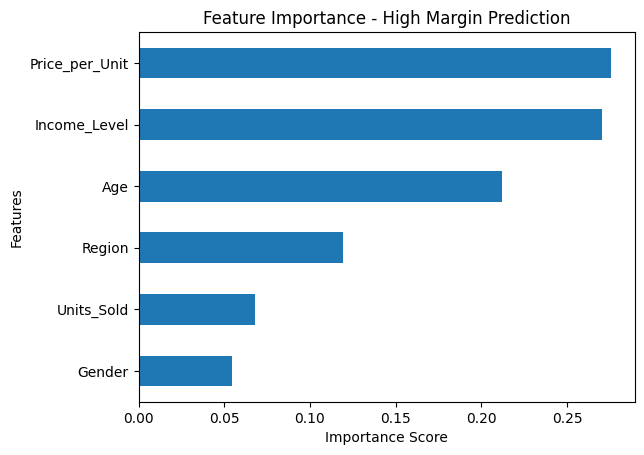

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance series
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Plot feature importance
importances.sort_values().plot(kind='barh')

plt.title('Feature Importance - High Margin Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()